# Universidad del Valle de Guatemala
## CC3092 - Deep Learning
## Hoja de trabajo 2

# DCGAN desde cero. Generación de sprites de Pokémon

**Integrantes:** 
- Dulce Ambrosio - 231143
- Angie Vela - 23764
---
## Descripcion general

Implementación de una DCGAN con PyTorch para generar sprites de Pokémon de 64×64 RGB. 
El dataset se construye a partir del repositorio público de sprites de PokeAPI en 
GitHub (898 imágenes, todas las generaciones).



# TASK 1
---

## 0. Configuración e imports

In [1]:
import os
import time
import random
import requests
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

Usando device: cpu


In [2]:
# Parametros fijos del enunciado
Z_DIM = 100
IMG_SIZE = 64
IMG_CHANNELS = 3
FEATURES_G = 64
FEATURES_D = 64

# Hiperparametros de entrenamiento
BATCH_SIZE = 32
NUM_EPOCHS = 50
LR = 2e-4
BETAS = (0.5, 0.999)

DATA_DIR = "pokemon_sprites"
OUT_DIR = "outputs"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Dataset — descarga de sprites desde PokeAPI (GitHub)

Si ya cuenta con el script proporcionado en la plataforma para construir el
dataset, puede usarlo directamente y saltar a la sección "Carga del dataset".
La celda siguiente es una alternativa autocontenida que descarga los sprites
`front_default` oficiales del repositorio público `PokeAPI/sprites`
(carpeta `sprites/pokemon`) para las 898 especies (Pokédex nacional hasta
Gen 8) y las guarda localmente redimensionadas a 64×64.

In [3]:
from PIL import Image

SPRITES_BASE_URL = (
    "https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon"
)
N_POKEMON = 898  # Pokedex nacional completa hasta Gen 8


def download_pokemon_sprites(n=N_POKEMON, out_dir=DATA_DIR, size=IMG_SIZE):
    """Descarga los sprites front_default de PokeAPI y los guarda como PNG
    RGB de (size x size) en out_dir. Omite descargas ya existentes, por lo
    que la celda se puede volver a correr sin costo extra."""
    downloaded, skipped, failed = 0, 0, 0
    for pid in range(1, n + 1):
        dst_path = os.path.join(out_dir, f"{pid:04d}.png")
        if os.path.exists(dst_path):
            skipped += 1
            continue
        url = f"{SPRITES_BASE_URL}/{pid}.png"
        try:
            resp = requests.get(url, timeout=15)
            resp.raise_for_status()
            img = Image.open(BytesIO(resp.content)).convert("RGBA")

            # Componer sobre fondo blanco (los sprites tienen canal alpha)
            bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
            img = Image.alpha_composite(bg, img).convert("RGB")
            img = img.resize((size, size), Image.LANCZOS)
            img.save(dst_path)
            downloaded += 1
        except Exception as e:
            failed += 1
            print(f"  [!] fallo id={pid}: {e}")

        if pid % 100 == 0:
            print(f"  progreso: {pid}/{n}")

    print(f"Descarga completa. nuevas={downloaded} ya_existian={skipped} fallidas={failed}")


# Descomentar para descargar (requiere acceso a GitHub raw content)
download_pokemon_sprites()


Descarga completa. nuevas=0 ya_existian=898 fallidas=0


## 2. Carga del dataset

In [4]:
class PokemonSpriteDataset(Dataset):
    """Dataset de imagenes RGB 64x64 leidas de disco."""

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.files = sorted(
            f for f in os.listdir(root_dir) if f.lower().endswith(".png")
        )
        if len(self.files) == 0:
            raise RuntimeError(
                f"No se encontraron imagenes en '{root_dir}'. "
                "Corra la celda de descarga o el script de la plataforma primero."
            )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.root_dir, self.files[idx])
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img


# Normalizacion a [-1, 1] para que coincida con la salida Tanh del generador
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * IMG_CHANNELS, [0.5] * IMG_CHANNELS),
])

dataset = PokemonSpriteDataset(DATA_DIR, transform=transform)
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
)
print(f"Dataset cargado: {len(dataset)} imagenes, {len(dataloader)} batches/epoca")

Dataset cargado: 898 imagenes, 28 batches/epoca


## 3. Task 1.1 — Arquitectura

**Generador**: 5 capas `ConvTranspose2d` con canales
`[FEATURES_G*8, FEATURES_G*4, FEATURES_G*2, FEATURES_G, IMG_CHANNELS]`.
BatchNorm2d + ReLU después de cada capa excepto la última (Tanh).

**Discriminador**: 5 capas `Conv2d` con stride 2 y canales
`[FEATURES_D, FEATURES_D*2, FEATURES_D*4, FEATURES_D*8, 1]`.
BatchNorm2d + LeakyReLU(0.2) después de cada capa excepto la primera y la
última (Sigmoid).

In [5]:
class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, features_g=FEATURES_G, img_channels=IMG_CHANNELS):
        super().__init__()
        self.net = nn.Sequential(
            # z: (batch, z_dim, 1, 1) -> (batch, features_g*8, 4, 4)
            self._block(z_dim, features_g * 8, kernel=4, stride=1, padding=0),
            # -> (batch, features_g*4, 8, 8)
            self._block(features_g * 8, features_g * 4, kernel=4, stride=2, padding=1),
            # -> (batch, features_g*2, 16, 16)
            self._block(features_g * 4, features_g * 2, kernel=4, stride=2, padding=1),
            # -> (batch, features_g, 32, 32)
            self._block(features_g * 2, features_g, kernel=4, stride=2, padding=1),
            # -> (batch, img_channels, 64, 64)
            nn.ConvTranspose2d(
                features_g, img_channels, kernel_size=4, stride=2, padding=1, bias=False
            ),
            nn.Tanh(),
        )

    @staticmethod
    def _block(in_c, out_c, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, features_d=FEATURES_D, img_channels=IMG_CHANNELS):
        super().__init__()
        self.net = nn.Sequential(
            # (batch, img_channels, 64, 64) -> (batch, features_d, 32, 32)
            # primera capa: sin BatchNorm (regla de Radford et al.)
            nn.Conv2d(img_channels, features_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # -> (batch, features_d*2, 16, 16)
            self._block(features_d, features_d * 2, kernel=4, stride=2, padding=1),
            # -> (batch, features_d*4, 8, 8)
            self._block(features_d * 2, features_d * 4, kernel=4, stride=2, padding=1),
            # -> (batch, features_d*8, 4, 4)
            self._block(features_d * 4, features_d * 8, kernel=4, stride=2, padding=1),
            # -> (batch, 1, 1, 1) : ultima capa, sin BatchNorm, con Sigmoid
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid(),
        )

    @staticmethod
    def _block(in_c, out_c, kernel, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    """Inicializacion recomendada por Radford et al. (2015): N(0, 0.02)."""
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [6]:
# Verificacion de formas exactas (requerimiento del enunciado)
G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

z = torch.randn(4, Z_DIM, 1, 1, device=device)
assert G(z).shape == (4, 3, 64, 64), "Forma del generador incorrecta"
assert D(torch.randn(4, 3, 64, 64, device=device)).shape == (4,), "Forma del discriminador incorrecta"
print("Formas verificadas correctamente.")
print(G)
print(D)

Formas verificadas correctamente.
Generator(
  (net): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (3): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1

## 4. Task 1.2 — Entrenamiento alternado

Por cada batch:

1. **Paso del discriminador** (maximizar $\theta_D$): pérdida sobre reales con
   etiqueta 1 + pérdida sobre falsas (`.detach()`) con etiqueta 0. Se suman y
   se actualiza $\theta_D$.
2. **Paso del generador** (minimizar $\theta_G$, truco de Goodfellow): nuevas
   imágenes falsas evaluadas por $D$ con etiqueta 1 (quiere engañar a $D$).

`BCELoss`, `Adam(lr=2e-4, betas=(0.5, 0.999))` para ambas redes,
`batch_size=32`, 50 épocas.

In [7]:
criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

# Ruido fijo para visualizar la evolucion del generador a lo largo del entrenamiento
FIXED_NOISE = torch.randn(16, Z_DIM, 1, 1, device=device)

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

history = {"loss_G": [], "loss_D": []}
snapshot_grids = []  # una grilla 4x4 por epoca (con FIXED_NOISE)

In [8]:
def train_one_epoch():
    G.train()
    D.train()
    epoch_loss_G, epoch_loss_D = 0.0, 0.0

    for real_imgs in dataloader:
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # -------------------------------------------------
        # Paso del discriminador: max log(D(x)) + log(1 - D(G(z)))
        # -------------------------------------------------
        opt_D.zero_grad()

        real_labels = torch.full((b_size,), REAL_LABEL, device=device)
        pred_real = D(real_imgs)
        loss_D_real = criterion(pred_real, real_labels)

        noise = torch.randn(b_size, Z_DIM, 1, 1, device=device)
        fake_imgs = G(noise)
        fake_labels = torch.full((b_size,), FAKE_LABEL, device=device)
        # detach() para NO propagar gradiente hacia G en este paso
        pred_fake = D(fake_imgs.detach())
        loss_D_fake = criterion(pred_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # -------------------------------------------------
        # Paso del generador: min log(1 - D(G(z)))  ==  max log(D(G(z)))
        # (truco de Goodfellow: usar etiquetas reales para el gradiente de G)
        # -------------------------------------------------
        opt_G.zero_grad()

        pred_fake_for_G = D(fake_imgs)  # sin detach: el gradiente si fluye a G
        gen_labels = torch.full((b_size,), REAL_LABEL, device=device)
        loss_G = criterion(pred_fake_for_G, gen_labels)
        loss_G.backward()
        opt_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    n_batches = len(dataloader)
    return epoch_loss_G / n_batches, epoch_loss_D / n_batches

In [9]:
start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    avg_loss_G, avg_loss_D = train_one_epoch()
    history["loss_G"].append(avg_loss_G)
    history["loss_D"].append(avg_loss_D)

    with torch.no_grad():
        G.eval()
        fake_grid = G(FIXED_NOISE).detach().cpu()
        G.train()
    snapshot_grids.append(fake_grid)

    grid = vutils.make_grid(fake_grid, nrow=4, normalize=True, value_range=(-1, 1))
    vutils.save_image(grid, os.path.join(OUT_DIR, f"epoch_{epoch:03d}.png"))

    print(
        f"Epoca [{epoch:02d}/{NUM_EPOCHS}] "
        f"loss_G={avg_loss_G:.4f}  loss_D={avg_loss_D:.4f}  "
        f"({time.time() - start:.1f}s transcurridos)"
    )

torch.save(G.state_dict(), os.path.join(OUT_DIR, "generator_final.pt"))
torch.save(D.state_dict(), os.path.join(OUT_DIR, "discriminator_final.pt"))
print("Entrenamiento finalizado. Pesos guardados en outputs/.")

Epoca [01/50] loss_G=10.6369  loss_D=0.3862  (30.7s transcurridos)


Epoca [02/50] loss_G=14.7712  loss_D=0.6555  (46.6s transcurridos)


Epoca [03/50] loss_G=11.8915  loss_D=1.6362  (61.7s transcurridos)


Epoca [04/50] loss_G=6.8294  loss_D=0.6672  (77.5s transcurridos)


Epoca [05/50] loss_G=8.0727  loss_D=0.5451  (92.6s transcurridos)


...

Epoca [46/50] loss_G=5.3687  loss_D=0.3748  (747.1s transcurridos)


Epoca [47/50] loss_G=4.9125  loss_D=0.4236  (762.7s transcurridos)


Epoca [48/50] loss_G=6.0999  loss_D=0.6810  (778.2s transcurridos)


Epoca [49/50] loss_G=4.5879  loss_D=0.3557  (794.4s transcurridos)


Epoca [50/50] loss_G=4.6107  loss_D=0.3081  (811.1s transcurridos)
Entrenamiento finalizado. Pesos guardados en outputs/.


## 5. Task 1.3 — Visualizaciones

### 5.1 Grilla 4×4 de imágenes generadas al final del entrenamiento
(desnormalizadas de [-1, 1] a [0, 255])

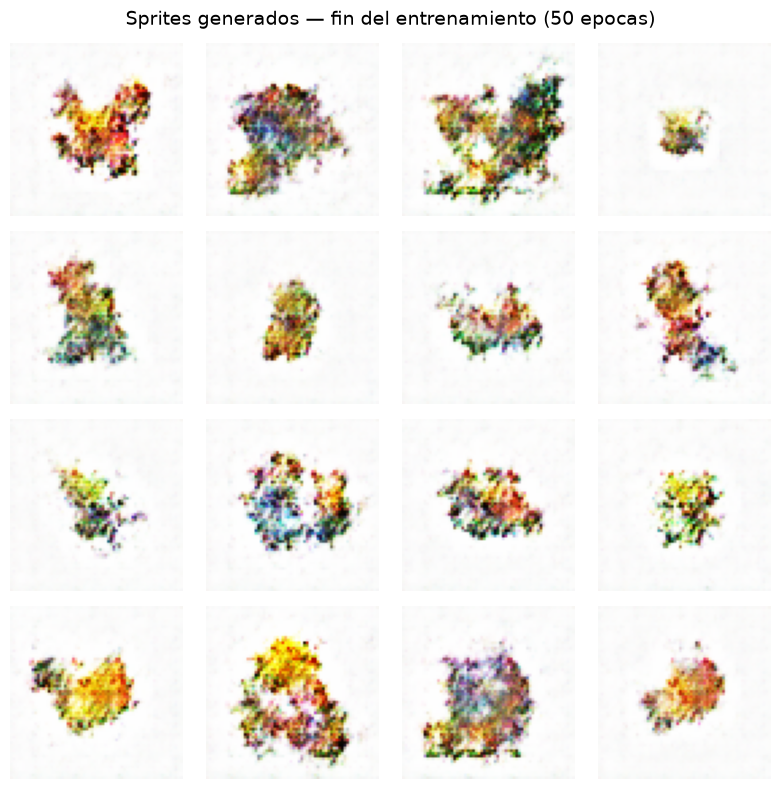

In [10]:
with torch.no_grad():
    G.eval()
    final_fake = G(FIXED_NOISE).detach().cpu()
    G.train()

# Desnormalizar de [-1, 1] a [0, 255]
final_imgs = (final_fake + 1) / 2.0  # -> [0, 1]
final_imgs = (final_imgs * 255).clamp(0, 255).to(torch.uint8)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for idx, ax in enumerate(axes.flat):
    img = final_imgs[idx].permute(1, 2, 0).numpy()  # (H, W, C)
    ax.imshow(img)
    ax.axis("off")

fig.suptitle("Sprites generados — fin del entrenamiento (50 epocas)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "grid_final_4x4.png"), dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Curvas de loss_G y loss_D a lo largo de las 50 épocas

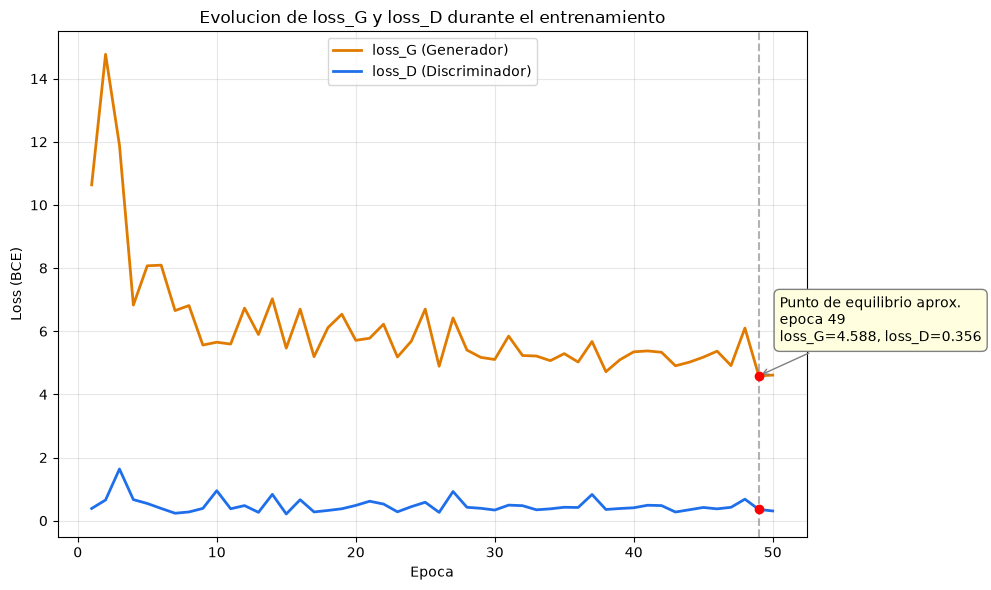

Punto mas cercano entre loss_G y loss_D: epoca 49 (|diff|=4.2322)


In [11]:
epochs = np.arange(1, NUM_EPOCHS + 1)
loss_G_arr = np.array(history["loss_G"])
loss_D_arr = np.array(history["loss_D"])

# Punto donde las perdidas estan mas cerca entre si (proxy de equilibrio)
diff = np.abs(loss_G_arr - loss_D_arr)
closest_idx = int(np.argmin(diff))
closest_epoch = epochs[closest_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, loss_G_arr, label="loss_G (Generador)", color="#e07b00", linewidth=2)
ax.plot(epochs, loss_D_arr, label="loss_D (Discriminador)", color="#1f6feb", linewidth=2)

ax.axvline(closest_epoch, color="gray", linestyle="--", alpha=0.6)
ax.scatter(
    [closest_epoch, closest_epoch],
    [loss_G_arr[closest_idx], loss_D_arr[closest_idx]],
    color="red",
    zorder=5,
)
ax.annotate(
    f"Punto de equilibrio aprox.\nepoca {closest_epoch}\n"
    f"loss_G={loss_G_arr[closest_idx]:.3f}, loss_D={loss_D_arr[closest_idx]:.3f}",
    xy=(closest_epoch, max(loss_G_arr[closest_idx], loss_D_arr[closest_idx])),
    xytext=(15, 25),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="gray"),
    arrowprops=dict(arrowstyle="->", color="gray"),
)

ax.set_xlabel("Epoca")
ax.set_ylabel("Loss (BCE)")
ax.set_title("Evolucion de loss_G y loss_D durante el entrenamiento")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

print(
    f"Punto mas cercano entre loss_G y loss_D: epoca {closest_epoch} "
    f"(|diff|={diff[closest_idx]:.4f})"
)

## Notas

- Si el entrenamiento diverge, debemos revisar el mode collapse (todas las muestras
  parecen iguales), vanishing gradients (loss_D cerca de 0 y loss_G creciendo
  sin control), u oscilación sin convergencia.
- `snapshot_grids` guarda una grilla por época con el mismo `FIXED_NOISE`,
  útil para armar un GIF de la evolución del generador.
- Los pesos finales quedan en `outputs/generator_final.pt` y
  `outputs/discriminator_final.pt`.